# Session 8, Notebook 3: The 2-D Poisson Equation, Soft against Hard Boundary Conditions

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 2, 14:00-14:55, Physics-informed neural networks: foundations
**Slides:** `08_PINNs_Foundations.pdf`
**Notebook role:** self-study
**Author:** Simon Scheidegger (HEC, University of Lausanne)

The 1-D comparison of Notebook 2 in two dimensions,

$$\Delta u = f \ \text{ on } (0,1)^2, \qquad u = g \ \text{ on the boundary},$$

with a manufactured solution $u^\star(x,y) = x^2 + y + \sin(\pi x)\sin(\pi y)$, so that
$f = 2 - 2\pi^2 \sin(\pi x)\sin(\pi y)$ and $g$ is $u^\star$ restricted to the four sides. In 2-D
the hard boundary conditions need one more idea: a function $A(x,y)$ that matches the boundary
data on all four sides, which transfinite interpolation provides. Both runs use the same network,
seed, sampling and optimizer schedule, Adam on resampled points followed by L-BFGS on a fixed set.

| Section | Content |
|:--|:--|
| 1 | Exact solution, forcing term, boundary data |
| 2 | Network and the Laplacian by autograd |
| 3 | Soft boundary conditions |
| 4 | Hard boundary conditions by transfinite interpolation |
| 5 | Comparison |

In [1]:
SEED = 42

In [2]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(SEED); np.random.seed(SEED)
torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                     "legend.fontsize": 9, "font.family": "serif", "mathtext.fontset": "cm",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
C_TRUE, C_SOFT, C_HARD = "#264653", "#e76f51", "#2a9d8f"

FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = True   # the stored run writes the figures the slides use
def savefig(fig, name):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
PI = np.pi

## 1. Exact solution, forcing term, boundary data

In [3]:
def u_exact(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    return x**2 + y + torch.sin(PI * x) * torch.sin(PI * y)

def f_forcing(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    return 2.0 - 2.0 * PI**2 * torch.sin(PI * x) * torch.sin(PI * y)

# the four sides of the square, as functions of the coordinate that varies along the side
g_left   = lambda y: y                 # u(0, y)
g_right  = lambda y: 1.0 + y           # u(1, y)
g_bottom = lambda x: x**2              # u(x, 0)
g_top    = lambda x: x**2 + 1.0        # u(x, 1)
c00, c10, c01, c11 = 0.0, 1.0, 1.0, 2.0   # corner values u(0,0), u(1,0), u(0,1), u(1,1)

def sample_interior(n):
    return torch.rand(n, 2)

def sample_boundary(n_per_side):
    t = torch.rand(n_per_side, 1); z, o = torch.zeros_like(t), torch.ones_like(t)
    xy = torch.cat([torch.cat([z, t], 1), torch.cat([o, t], 1), torch.cat([t, z], 1), torch.cat([t, o], 1)], 0)
    return xy, u_exact(xy)

## 2. Network and the Laplacian

Two inputs, four hidden layers of 64 `tanh` units. The Laplacian is the sum of two second
derivatives, each obtained by differentiating the gradient once more with respect to one coordinate.

In [4]:
class MLP2D(nn.Module):
    def __init__(self, widths=(2, 64, 64, 64, 64, 1)):
        super().__init__()
        layers = []
        for i in range(len(widths) - 1):
            layers.append(nn.Linear(widths[i], widths[i + 1]))
            if i < len(widths) - 2:
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, xy):
        return self.net(xy)

def laplacian(u, xy):
    grad = torch.autograd.grad(u, xy, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(grad[:, 0:1], xy, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 0:1]
    u_yy = torch.autograd.grad(grad[:, 1:2], xy, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 1:2]
    return u_xx + u_yy

# check on the exact solution: its Laplacian must equal f
xy_chk = torch.rand(5, 2).requires_grad_(True)
print("max |Laplacian(u*) - f| on random points:", (laplacian(u_exact(xy_chk), xy_chk) - f_forcing(xy_chk)).abs().max().item())

max |Laplacian(u*) - f| on random points: 2.220446049250313e-16


## 3. Soft boundary conditions

The loss is the interior residual plus ten times the mean squared boundary mismatch on 256 points
per side. Adam for 5,000 steps with the points redrawn every 200 steps and a cosine learning-rate
decay, then L-BFGS on a fixed set of 4,096 interior and 2,048 boundary points.

In [5]:
N_ADAM, N_LBFGS, N_INT, N_BC_SIDE, BC_WEIGHT = 5000, 300, 2048, 256, 10.0

def train(u_of, loss_fn, seed=SEED):
    """Adam on resampled points, then L-BFGS on a fixed set. Returns (loss after Adam, loss after L-BFGS, evals, seconds)."""
    torch.manual_seed(seed)
    params = [p for p in u_of.parameters()]
    opt = torch.optim.Adam(params, lr=1e-3); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, N_ADAM)
    t0 = time.time()
    for step in range(N_ADAM):
        if step % 200 == 0:
            xy_int = sample_interior(N_INT); bc = sample_boundary(N_BC_SIDE)
        loss = loss_fn(xy_int, bc); opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        if (step + 1) % 2000 == 0:
            print(f"  Adam step {step + 1:5d}  loss {loss.item():.3e}")
    loss_adam = loss.item(); t_adam = time.time() - t0
    xy_fix = sample_interior(2 * N_INT); bc_fix = sample_boundary(2 * N_BC_SIDE)
    lbfgs = torch.optim.LBFGS(params, max_iter=N_LBFGS, history_size=50, tolerance_grad=1e-12,
                              tolerance_change=1e-14, line_search_fn="strong_wolfe")
    n_eval = [0]
    def closure():
        lbfgs.zero_grad(); l = loss_fn(xy_fix, bc_fix); l.backward(); n_eval[0] += 1; return l
    t0 = time.time(); lbfgs.step(closure); t_lbfgs = time.time() - t0
    loss_lbfgs = loss_fn(xy_fix, bc_fix).item()
    print(f"  Adam: loss {loss_adam:.3e} in {t_adam:.0f} s;  L-BFGS: loss {loss_lbfgs:.3e} after {n_eval[0]} evaluations in {t_lbfgs:.0f} s")
    return loss_adam, loss_lbfgs

model_soft = MLP2D()
def loss_soft(xy_int, bc):
    xy = xy_int.clone().requires_grad_(True)
    res = laplacian(model_soft(xy), xy) - f_forcing(xy)
    return torch.mean(res**2) + BC_WEIGHT * torch.mean((model_soft(bc[0]) - bc[1])**2)

print("soft boundary conditions"); loss_soft_adam, loss_soft_lbfgs = train(model_soft, loss_soft)

soft boundary conditions


  Adam step  2000  loss 1.455e-03


  Adam step  4000  loss 4.383e-04


  Adam: loss 4.117e-04 in 240 s;  L-BFGS: loss 5.741e-05 after 318 evaluations in 34 s


## 4. Hard boundary conditions by transfinite interpolation

$$\hat u(x,y) = A(x,y) + \underbrace{x(1-x)\,y(1-y)}_{B(x,y)}\,N_\theta(x,y),$$

where $A$ must equal $g$ on all four sides. Interpolating the two vertical sides linearly in $x$
and the two horizontal sides linearly in $y$ counts every corner twice, so the bilinear
interpolant of the corner values is subtracted once:

$$A = (1-x)\,g_L(y) + x\,g_R(y) + (1-y)\,g_B(x) + y\,g_T(x)
    - \bigl[(1-x)(1-y)\,c_{00} + x(1-y)\,c_{10} + (1-x)y\,c_{01} + xy\,c_{11}\bigr].$$

On the boundary $B = 0$, so $\hat u = A = g$ exactly, and the loss is the residual alone.

In [6]:
def A_lifting(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    val = (1 - x) * g_left(y) + x * g_right(y) + (1 - y) * g_bottom(x) + y * g_top(x)
    return val - ((1 - x) * (1 - y) * c00 + x * (1 - y) * c10 + (1 - x) * y * c01 + x * y * c11)

def B_mask(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    return x * (1 - x) * y * (1 - y)

class HardBC(nn.Module):
    def __init__(self, raw):
        super().__init__(); self.raw = raw
    def forward(self, xy):
        return A_lifting(xy) + B_mask(xy) * self.raw(xy)

xy_b, u_b = sample_boundary(100)
print("max |A - g| on the boundary:", (A_lifting(xy_b) - u_b).abs().max().item())

torch.manual_seed(SEED); model_hard = HardBC(MLP2D())
def loss_hard(xy_int, bc):
    xy = xy_int.clone().requires_grad_(True)
    res = laplacian(model_hard(xy), xy) - f_forcing(xy)
    return torch.mean(res**2)

print("hard boundary conditions"); loss_hard_adam, loss_hard_lbfgs = train(model_hard, loss_hard)

max |A - g| on the boundary: 4.440892098500626e-16
hard boundary conditions


  Adam step  2000  loss 4.894e-04


  Adam step  4000  loss 1.732e-04


  Adam: loss 1.581e-04 in 274 s;  L-BFGS: loss 6.251e-06 after 319 evaluations in 38 s


## 5. Comparison

relative L2 error: soft 1.38e-04, hard 3.65e-06, ratio 37.7
max |error|:       soft 1.55e-03, hard 1.44e-05
max |error| on the boundary: soft 1.55e-03, hard 4.4e-16


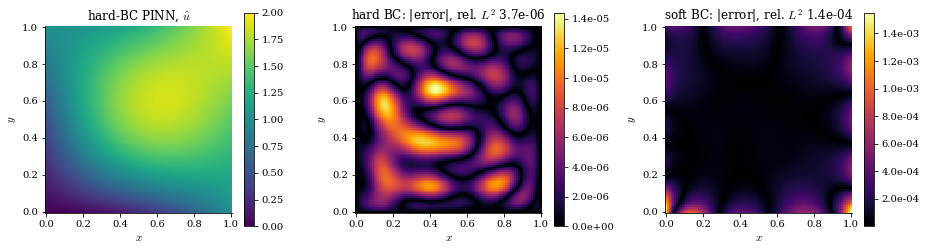

In [7]:
g = torch.linspace(0, 1, 101); X, Y = torch.meshgrid(g, g, indexing="ij")
xy_grid = torch.stack([X.reshape(-1), Y.reshape(-1)], 1)
with torch.no_grad():
    U_true = u_exact(xy_grid).reshape(101, 101).numpy()
    U_soft = model_soft(xy_grid).reshape(101, 101).numpy()
    U_hard = model_hard(xy_grid).reshape(101, 101).numpy()
rel_l2 = lambda U: np.linalg.norm(U - U_true) / np.linalg.norm(U_true)
err_soft, err_hard = rel_l2(U_soft), rel_l2(U_hard)
bnd = np.r_[np.abs(U_soft - U_true)[0, :], np.abs(U_soft - U_true)[-1, :], np.abs(U_soft - U_true)[:, 0], np.abs(U_soft - U_true)[:, -1]]
print(f"relative L2 error: soft {err_soft:.2e}, hard {err_hard:.2e}, ratio {err_soft / err_hard:.1f}")
print(f"max |error|:       soft {np.abs(U_soft - U_true).max():.2e}, hard {np.abs(U_hard - U_true).max():.2e}")
print(f"max |error| on the boundary: soft {bnd.max():.2e}, hard {np.abs(np.r_[(U_hard - U_true)[0, :], (U_hard - U_true)[-1, :], (U_hard - U_true)[:, 0], (U_hard - U_true)[:, -1]]).max():.1e}")

Xn, Yn = X.numpy(), Y.numpy()
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
c0 = axes[0].pcolormesh(Xn, Yn, U_hard, cmap="viridis", shading="auto", rasterized=True); fig.colorbar(c0, ax=axes[0]); axes[0].set_title("hard-BC PINN, $\\hat u$")
c1 = axes[1].pcolormesh(Xn, Yn, np.abs(U_hard - U_true), cmap="inferno", shading="auto", rasterized=True); fig.colorbar(c1, ax=axes[1], format="%.1e"); axes[1].set_title(f"hard BC: |error|, rel. $L^2$ {err_hard:.1e}")
c2 = axes[2].pcolormesh(Xn, Yn, np.abs(U_soft - U_true), cmap="inferno", shading="auto", rasterized=True); fig.colorbar(c2, ax=axes[2], format="%.1e"); axes[2].set_title(f"soft BC: |error|, rel. $L^2$ {err_soft:.1e}")
for ax in axes:
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_aspect("equal"); ax.grid(False)
fig.tight_layout(); savefig(fig, "pinn_poisson2d"); plt.show()

## Summary

* Same network, seed, sampling and schedule; only the boundary treatment differs. Relative $L^2$
  error $1.4\times10^{-4}$ with the soft penalty against $3.7\times10^{-6}$ with the hard trial solution,
  a factor 38. The soft run's largest error, $1.6\times10^{-3}$, sits on the boundary; the hard run's
  boundary error is $10^{-16}$, machine precision, because $B = 0$ there.
* Transfinite interpolation is the 2-D version of $A(x) = 1 + x$: interpolate the four sides and
  subtract the corners once. It needs the boundary data in closed form, which is the price of hard
  boundary conditions on a domain with several sides.
* The same recipe as in 1-D, Adam on resampled points and L-BFGS on a fixed set, does the same job
  here: L-BFGS lowers the loss by another factor 7 (soft) and 25 (hard) after Adam.